# Zeitreihenanalyse

In diesem Notebook werden verschiedene Zeitreihendatensätze analysiert und miteinander verglichen. Ziel ist es, grundlegende Muster, Verteilungen und zeitliche Eigenschaften der Daten zu untersuchen.

## 1. Bibliotheken importieren

Für die Analyse werden Bibliotheken zur Datenverarbeitung, Visualisierung und Modellierung verwendet.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 2. Datensätze laden

Die Datensätze für Amazon Sales, Apple Stock und Wetterdaten werden eingelesen und anschließend überprüft.

In [38]:

amazon = pd.read_csv("data/raw/amazon_sales_dataset.csv", low_memory=False, sep=";")
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")


## 3. Überblick über die Datensätze

Zur ersten Orientierung werden die Dimensionen und die ersten Zeilen der Datensätze angezeigt.

In [39]:
datasets = {
    "Amazon Sales": amazon,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)

Amazon Sales
(50000, 13)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


Apple Stock
(2596, 6)


,Price,Close,High,Low,Open,Volume
0,2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
1,2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2,2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
3,2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
4,2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### Stil setzen

**Datenbereinigung**

In [40]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Amazon Sales plt

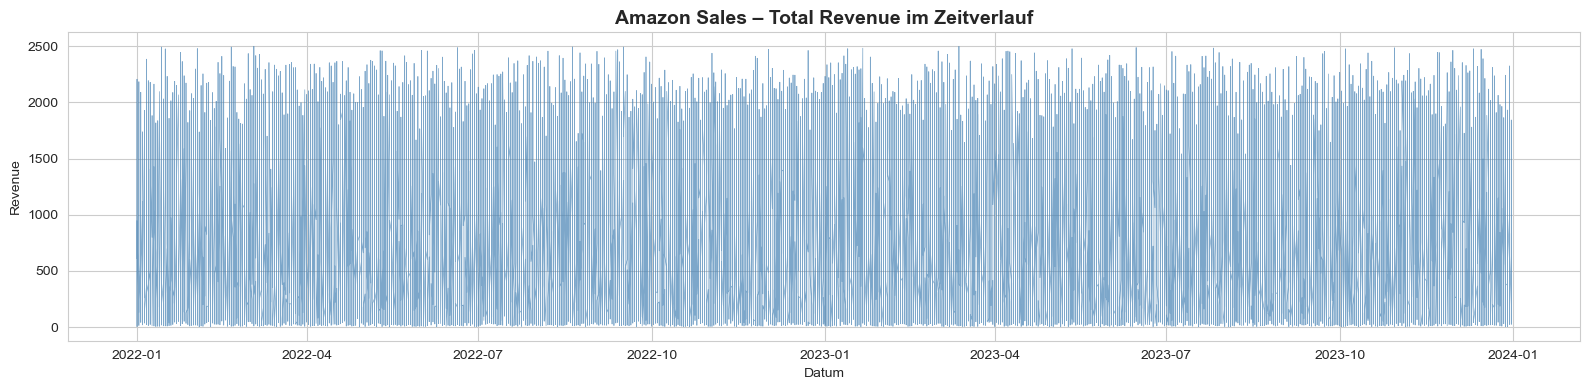

In [41]:
# --- Amazon Sales ---
df_amazon = amazon.copy()
df_amazon["order_date"] = pd.to_datetime(df_amazon["order_date"])
df_amazon = df_amazon.sort_values("order_date")

# 1. Total Revenue über Zeit
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_amazon["order_date"], df_amazon["total_revenue"], 
        color="steelblue", linewidth=0.5, alpha=0.7)
ax.set_title("Amazon Sales – Total Revenue im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Revenue")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()


### Apple Stock plt

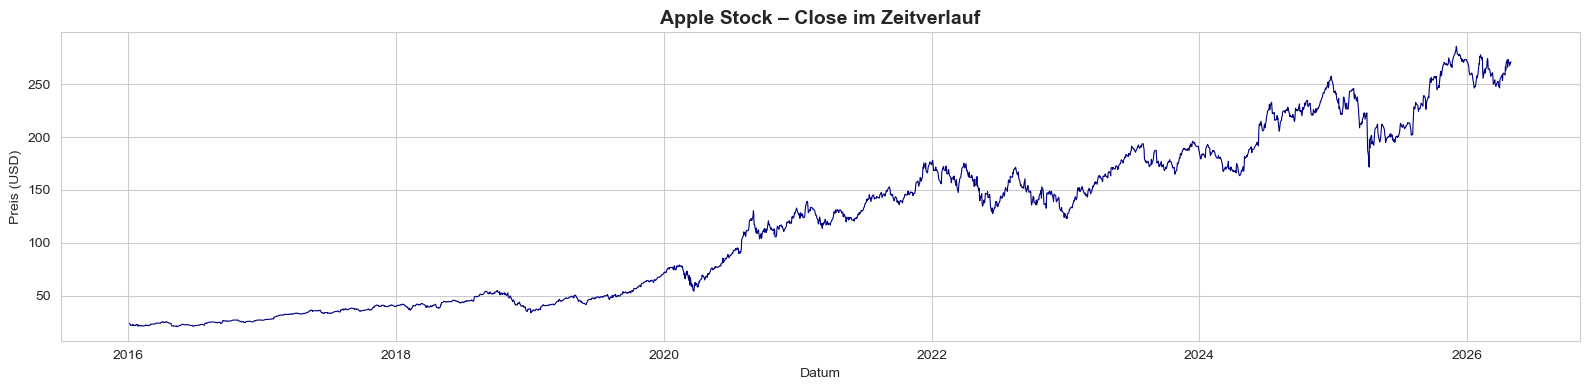

In [42]:
# --- Apple Stock ---
df_apple = apple.copy()
df_apple["Price"] = pd.to_datetime(df_apple["Price"])
df_apple = df_apple.rename(columns={"Price": "Date"}).set_index("Date")

# 5. Close über Zeit
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_apple.index, df_apple["Close"], color="navy", linewidth=0.8)
ax.set_title("Apple Stock – Close im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Preis (USD)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()


### Weather plt

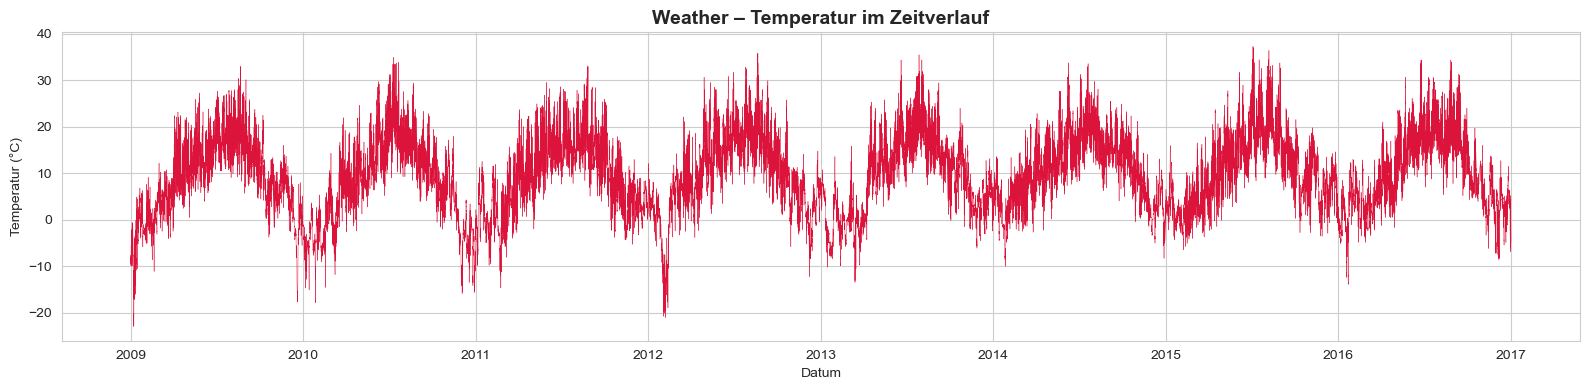

In [43]:
# --- Weather ---
df_weather = weather.copy()
df_weather["Date Time"] = pd.to_datetime(df_weather["Date Time"], format="%d.%m.%Y %H:%M:%S")
df_weather = df_weather.set_index("Date Time")

# 7. Temperatur
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_weather.index, df_weather["T (degC)"], color="crimson", linewidth=0.3)
ax.set_title("Weather – Temperatur im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()


In [44]:

def remove_outliers_iqr(df, columns):
    """Entfernt Ausreißer anhand der IQR-Methode (1.5 * IQR)."""
    mask = pd.Series(True, index=df.index)
    for col in columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= (df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)
    return df[mask]
 
amazon["order_date"] = pd.to_datetime(amazon["order_date"])
amazon = amazon.set_index("order_date").sort_index()
amazon = amazon.drop_duplicates()
amazon = amazon.dropna()
amazon = remove_outliers_iqr(amazon, ["total_revenue", "price"])
 
print("Amazon bereinigt:", amazon.shape)
 
 
# ─────────────────────────────────────────────
# 3. APPLE – Aktienkurse bereinigen
# ─────────────────────────────────────────────
 
apple = apple.rename(columns={"Price": "Date"})
apple["Date"] = pd.to_datetime(apple["Date"])
apple = apple.set_index("Date").sort_index()
for col in apple.columns:
    apple[col] = pd.to_numeric(apple[col], errors="coerce")
apple = apple.drop_duplicates()
apple = apple.dropna()
apple = remove_outliers_iqr(apple, ["Close"])
 
print("Apple bereinigt:", apple.shape)
 
 
# ─────────────────────────────────────────────
# 4. WEATHER – Wetterdaten bereinigen
# ─────────────────────────────────────────────
 
weather["Date Time"] = pd.to_datetime(weather["Date Time"], dayfirst=True)
weather = weather.set_index("Date Time").sort_index()
weather = weather.drop_duplicates()
weather = weather.dropna()
weather = weather[weather["wv (m/s)"] >= 0]
weather = weather[weather["max. wv (m/s)"] >= 0]
weather = remove_outliers_iqr(weather, ["T (degC)"])
 
print("Weather bereinigt:", weather.shape)
 
 
# ─────────────────────────────────────────────
# 5. WACHSTUMSRATEN berechnen
# (Menden Skript, Folie 15/16: Wachstumsraten)
# gt = (xt - xt-1) / xt-1
# ─────────────────────────────────────────────
 
amazon_daily = amazon["total_revenue"].resample("D").sum()
amazon["revenue_growth"] = amazon_daily.pct_change()
 
apple["close_growth"] = apple["Close"].pct_change()
 
weather["temp_diff"] = weather["T (degC)"].diff()
 
 
# ─────────────────────────────────────────────
# 6. ÜBERBLICK
# ─────────────────────────────────────────────
 
datasets_clean = {
    "Amazon Sales": amazon,
    "Apple Stock":  apple,
    "Weather":      weather,
}
 
for name, df in datasets_clean.items():
    print(f"\n{'─' * 45}")
    print(f" {name}")
    print(f"   Shape:       {df.shape}")
    print(f"   Zeitraum:    {df.index.min()}  →  {df.index.max()}")
    print(f"   NaN gesamt:  {df.isnull().sum().sum()}")
    print(f"   Dtype Index: {df.index.dtype}")

Amazon bereinigt: (49248, 12)
Apple bereinigt: (2596, 5)
Weather bereinigt: (418665, 14)

─────────────────────────────────────────────
 Amazon Sales
   Shape:       (49248, 13)
   Zeitraum:    2022-01-01 00:00:00  →  2023-12-31 00:00:00
   NaN gesamt:  66
   Dtype Index: datetime64[ns]

─────────────────────────────────────────────
 Apple Stock
   Shape:       (2596, 6)
   Zeitraum:    2016-01-04 00:00:00  →  2026-04-30 00:00:00
   NaN gesamt:  1
   Dtype Index: datetime64[ns]

─────────────────────────────────────────────
 Weather
   Shape:       (418665, 15)
   Zeitraum:    2009-01-01 00:10:00  →  2017-01-01 00:00:00
   NaN gesamt:  1
   Dtype Index: datetime64[ns]


# 8. Deskripitive Analyse

## Amazon 

Die deskriptive Analyse dient dazu, einen ersten Überblick über die täglichen Amazon-Umsätze zu erhalten. Dabei werden statistische Kennzahlen, die Verteilung der Umsätze sowie Unterschiede zwischen den Wochentagen untersucht.


Statistik:
       total_revenue
count     730.000000
mean    42737.454438
std      6613.714312
min     27837.550000
25%     37967.730000
50%     42516.035000
75%     47209.212500
max     63224.280000

Zeitraum:
2022-01-01 00:00:00 → 2023-12-31 00:00:00

NaN Werte:
total_revenue    0
dtype: int64


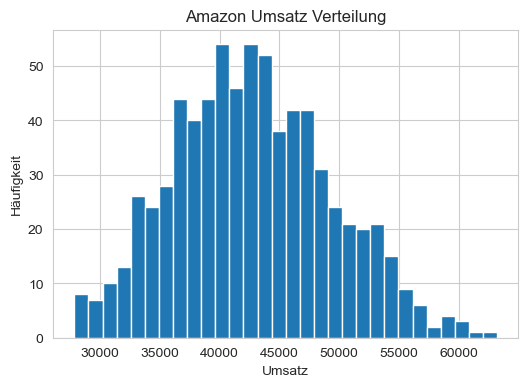

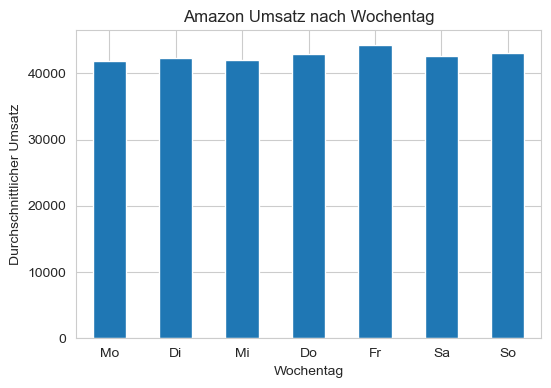

In [45]:
# AMAZON → täglicher Umsatz
amazon_daily = amazon["total_revenue"].resample("D").sum().to_frame()

print("\nStatistik:")
print(amazon_daily.describe())

print("\nZeitraum:")
print(amazon_daily.index.min(), "→", amazon_daily.index.max())

print("\nNaN Werte:")
print(amazon_daily.isnull().sum())


# Histogramm
plt.figure(figsize=(6,4))
plt.hist(amazon_daily["total_revenue"].dropna(), bins=30)
plt.title("Amazon Umsatz Verteilung")
plt.xlabel("Umsatz")
plt.ylabel("Häufigkeit")
plt.show()

# Wochentage
weekday_map = {
    0: "Mo",
    1: "Di",
    2: "Mi",
    3: "Do",
    4: "Fr",
    5: "Sa",
    6: "So"
}
weekday_order = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

amazon_daily["weekday"] = amazon_daily.index.dayofweek
amazon_daily["weekday_name"] = amazon_daily["weekday"].map(weekday_map)

amazon_daily["weekday_name"] = pd.Categorical(
    amazon_daily["weekday_name"],
    categories=weekday_order,
    ordered=True
)

plt.figure(figsize=(6,4))

amazon_daily.groupby(
    "weekday_name",
    observed=False
)["total_revenue"].mean().plot(kind="bar")

plt.title("Amazon Umsatz nach Wochentag")
plt.xlabel("Wochentag")
plt.ylabel("Durchschnittlicher Umsatz")

# Labels gerade anzeigen
plt.xticks(rotation=0)

plt.show()

Die durchschnittlichen täglichen Umsätze von Amazon liegen bei etwa 42.737. Die Umsätze schwanken dabei moderat, was durch die Standardabweichung sichtbar wird. Fehlende Werte sind im Datensatz nicht vorhanden.

Das Histogramm zeigt eine annähernd gleichmäßige Verteilung der Umsätze mit den meisten Werten im Bereich zwischen 38.000 und 48.000.

Die Analyse nach Wochentagen zeigt nur geringe Unterschiede. Besonders freitags und sonntags sind die durchschnittlichen Umsätze etwas höher als an den übrigen Tagen.

## Apple

Die deskriptive Analyse dient dazu, einen ersten Überblick über die täglichen Apple-Schlusskurse zu erhalten. Dabei werden statistische Kennzahlen, die Verteilung der Schlusskurse sowie mögliche Unterschiede zwischen den Wochentagen untersucht.


Statistik:
             Close
count  2596.000000
mean    118.832186
std      76.584117
min      20.584814
25%      41.935802
50%     123.907543
75%     175.758690
max     285.922455

Zeitraum:
2016-01-04 00:00:00 → 2026-04-30 00:00:00

NaN Werte:
Close    1174
dtype: int64


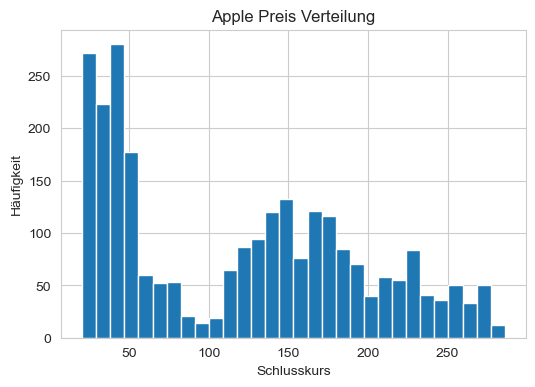

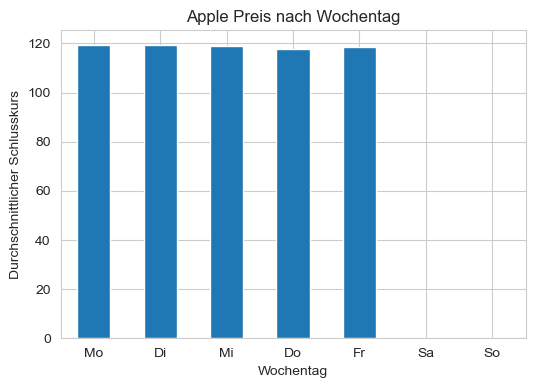

In [46]:
# APPLE → täglicher Schlusskurs
apple_daily = apple["Close"].resample("D").mean().to_frame()

print("\nStatistik:")
print(apple_daily.describe())

print("\nZeitraum:")
print(apple_daily.index.min(), "→", apple_daily.index.max())

print("\nNaN Werte:")
print(apple_daily.isnull().sum())


# Histogramm
plt.figure(figsize=(6,4))
plt.hist(apple_daily["Close"].dropna(), bins=30)
plt.title("Apple Preis Verteilung")
plt.xlabel("Schlusskurs")
plt.ylabel("Häufigkeit")
plt.show()


# Wochentage
weekday_map = {
    0: "Mo",
    1: "Di",
    2: "Mi",
    3: "Do",
    4: "Fr",
    5: "Sa",
    6: "So"
}

weekday_order = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

apple_daily["weekday"] = apple_daily.index.dayofweek
apple_daily["weekday_name"] = apple_daily["weekday"].map(weekday_map)

apple_daily["weekday_name"] = pd.Categorical(
    apple_daily["weekday_name"],
    categories=weekday_order,
    ordered=True
)

plt.figure(figsize=(6,4))

apple_daily.groupby(
    "weekday_name",
    observed=False
)["Close"].mean().plot(kind="bar")

plt.title("Apple Preis nach Wochentag")
plt.xlabel("Wochentag")
plt.ylabel("Durchschnittlicher Schlusskurs")

plt.xticks(rotation=0)

plt.show()

Der durchschnittliche tägliche Apple-Schlusskurs liegt bei etwa 118,83. Die Kurse weisen dabei eine relativ hohe Schwankung auf, was durch die Standardabweichung sichtbar wird. Zudem enthält der Datensatz einige fehlende Werte, da an Wochenenden und Feiertagen kein Börsenhandel stattfindet.

Das Histogramm zeigt eine breite Verteilung der Schlusskurse über verschiedene Preisbereiche hinweg.

Die Analyse nach Wochentagen zeigt kaum Unterschiede zwischen den einzelnen Handelstagen. Für Samstag und Sonntag liegen keine Werte vor, da die Börse an diesen Tagen geschlossen ist.

## Weather

Die deskriptive Analyse dient dazu, einen ersten Überblick über die täglichen Durchschnittstemperaturen zu erhalten. Dabei werden statistische Kennzahlen, die Verteilung der Temperaturen sowie mögliche Unterschiede zwischen den Wochentagen untersucht.


Statistik:
          T (degC)
count  2920.000000
mean      9.453875
std       7.767782
min     -13.646623
25%       3.812344
50%       9.712882
75%      15.427639
max      26.892778

Zeitraum:
2009-01-01 00:00:00 → 2017-01-01 00:00:00

NaN Werte:
T (degC)    3
dtype: int64


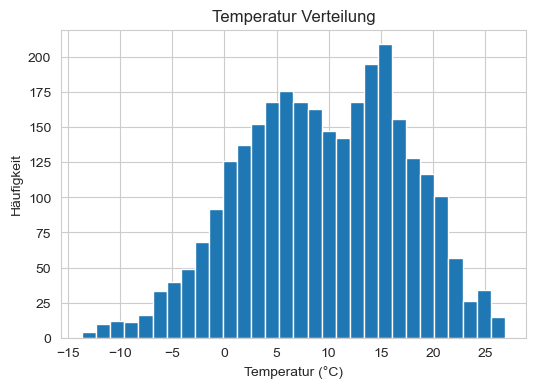

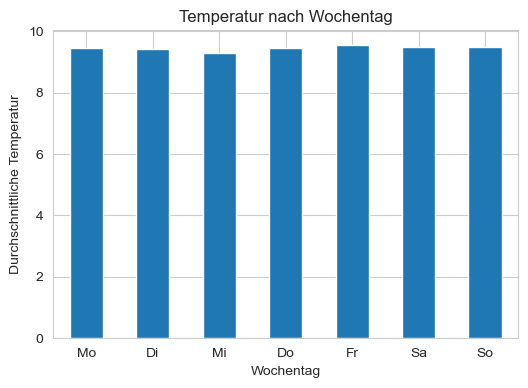

In [47]:
# WEATHER → tägliche Durchschnittstemperatur
weather_daily = weather["T (degC)"].resample("D").mean().to_frame()

print("\nStatistik:")
print(weather_daily.describe())

print("\nZeitraum:")
print(weather_daily.index.min(), "→", weather_daily.index.max())

print("\nNaN Werte:")
print(weather_daily.isnull().sum())


# Histogramm
plt.figure(figsize=(6,4))
plt.hist(weather_daily["T (degC)"].dropna(), bins=30)
plt.title("Temperatur Verteilung")
plt.xlabel("Temperatur (°C)")
plt.ylabel("Häufigkeit")
plt.show()


# Wochentage
weekday_map = {
    0: "Mo",
    1: "Di",
    2: "Mi",
    3: "Do",
    4: "Fr",
    5: "Sa",
    6: "So"
}

weekday_order = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

weather_daily["weekday"] = weather_daily.index.dayofweek
weather_daily["weekday_name"] = weather_daily["weekday"].map(weekday_map)

weather_daily["weekday_name"] = pd.Categorical(
    weather_daily["weekday_name"],
    categories=weekday_order,
    ordered=True
)

plt.figure(figsize=(6,4))

weather_daily.groupby(
    "weekday_name",
    observed=False
)["T (degC)"].mean().plot(kind="bar")

plt.title("Temperatur nach Wochentag")
plt.xlabel("Wochentag")
plt.ylabel("Durchschnittliche Temperatur")

plt.xticks(rotation=0)

plt.show()

Die durchschnittliche tägliche Temperatur liegt bei etwa 9,45 °C. Die Temperaturen schwanken dabei deutlich zwischen kalten Wintertagen und warmen Sommertagen. Im Datensatz sind nur sehr wenige fehlende Werte vorhanden.

Das Histogramm zeigt eine breite Verteilung der Temperaturen mit den meisten Werten im Bereich zwischen 0 °C und 20 °C.

Die Analyse nach Wochentagen zeigt nahezu keine Unterschiede zwischen den einzelnen Tagen, da die Temperatur nicht vom Wochentag abhängig ist.

# 9. Fazit

Die Analyse zeigt, dass sich die drei Datensätze deutlich in ihrer Struktur und Dynamik unterscheiden. Während die Amazon-Umsätze relativ stabil verlaufen, weisen die Apple-Aktienkurse stärkere Schwankungen auf. Die Wetterdaten zeigen dagegen typische saisonale Temperaturverläufe ohne erkennbare Unterschiede zwischen den Wochentagen.